<a href="https://colab.research.google.com/github/ck1894/NYU-Tandon-CS-GY-6923-Machine-Learning/blob/main/weeek_3_demo_overfitting_underfitting_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures # Creates polynomial feature expansions
from sklearn.linear_model import LinearRegression, Ridge, Lasso # Must explicitly use a regularized model if want regularization
from sklearn.pipeline import Pipeline # Chains preprocessing and model steps together
from sklearn.metrics import mean_squared_error

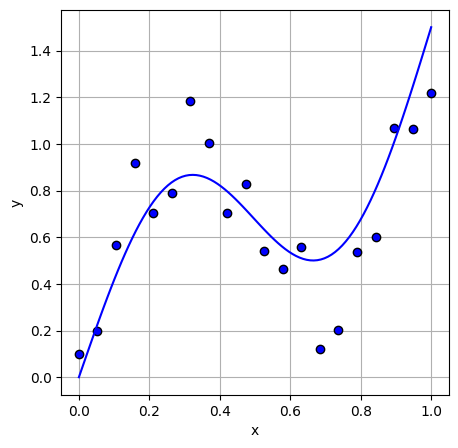

In [2]:
def generate_data(n_samples=50, noise_level=0.3, random_state=42):
    """
    Generate synthetic data with a true underlying function.
    We'll use a sine wave with some polynomial components - easy to understand!
    """
    np.random.seed(random_state)

    # Generate x values
    X = np.linspace(0, 1, n_samples) # create evenly spaced numbers between two values

    # True function: a combination of sine and polynomial
    # This represents some real-world relationship we're trying to learn
      # lambda arguments: expression
        # f = lambda x: x**2
        # f(3) returns 9
    true_function = lambda x: 1.2 * x + 0.5 * np.sin(2 * np.pi * x) + 0.3 * x**2
    y_true = true_function(X)

    # Add noise to make it realistic
    noise = np.random.normal(0, noise_level, n_samples)
    y = y_true + noise

    return X, y, y_true, true_function

# Generate training data
X_train, y_train, y_true_train, true_func = generate_data(n_samples=20, noise_level=0.2)

# Generate test data (more points for smooth plotting)
X_test = np.linspace(0, 1, 100)
y_true_test = true_func(X_test)

plt.figure(figsize=(5, 5))
plt.grid()
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X_train, y_train, "bo", mec="k")
plt.plot(X_test, y_true_test, "-b")

$y_{\text{true}} = 1.2 \cdot x + 0.5 \cdot \sin(2\pi x) + 0.3 \cdot x^2$

$y = y_{\text{true}} + \varepsilon, ~~ \varepsilon \sim N(0, 0.2^2)$

Features: $[1, x, x^2, \ldots, x^d]$

In [17]:
def create_polynomial_model(degree, alpha=0.0, l1=False):
    """
    Create a polynomial regression model with optional regularization.

    degree: polynomial degree
    alpha: regularization strength (0 = no regularization)
    """
    if alpha > 0:
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree)), # 'poly' is just a name for that pipeline step. It does NOT affect the math.
            (
              (
                'ridge', Ridge(alpha=alpha)
              ) if not l1 else (
                'Lasso', Lasso(alpha=alpha)
              )
            )
        ])
    else:
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree)),
            ('linear', LinearRegression())
        ])
    return model


models = {
    'Underfitting (degree=1)': {'degree': 1, 'color': 'red', 'alpha': 0.0},
    'Good Fit (degree=3)': {'degree': 3, 'color': 'green', 'alpha': 0.0},
    'Overfitting (degree=15)': {'degree': 15, 'color': 'orange', 'alpha': 0.0}
}

In [19]:
# Example to show what PolynomialFeatures does
# By default, `PolynomialFeatures` includes a bias term, which is: x^0 = 1

x = [[2]]
degree = 5
f = PolynomialFeatures(degree=degree)
f.fit_transform(x)

array([[ 1.,  2.,  4.,  8., 16., 32.]])

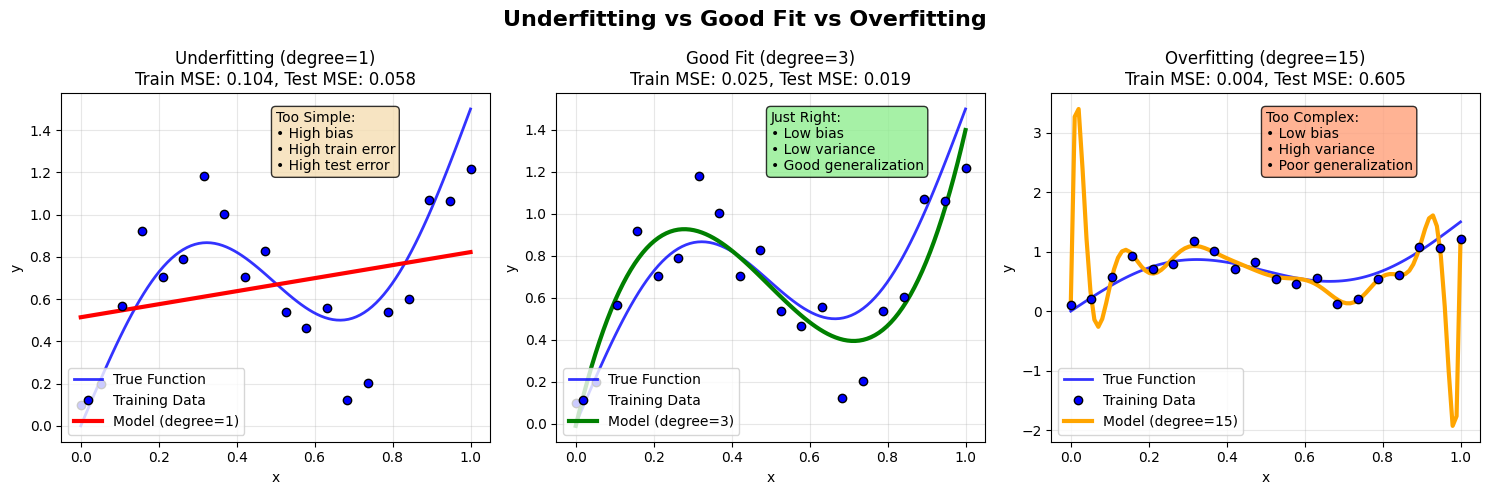

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Underfitting vs Good Fit vs Overfitting', fontsize=16, fontweight='bold')

for idx, (model_name, params) in enumerate(models.items()):
    ax = axes[idx]

    # Create and train model
    model = create_polynomial_model(params['degree'], params['alpha'])
    model.fit(X_train.reshape(-1, 1), y_train) # reshape(-1, 1) converts a 1D array into a 2D column vector so sklearn can treat it as one feature (20,) -> (20, 1)

    # Make predictions
    y_pred = model.predict(X_test.reshape(-1, 1))
    train_pred = model.predict(X_train.reshape(-1, 1))

    # Calculate errors
    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_true_test, y_pred)

    # Plot true function
    ax.plot(X_test, y_true_test, 'b-', linewidth=2, alpha=0.8, label='True Function')

    # Plot training data
    ax.plot(X_train, y_train, 'bo', mec="k",zorder=5, label='Training Data')

    # Plot model prediction
    ax.plot(X_test, y_pred, color=params['color'], linewidth=3,
            label=f'Model (degree={params["degree"]})')

    # Styling
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{model_name}\nTrain MSE: {train_error:.3f}, Test MSE: {test_error:.3f}')
    ax.legend(loc=3)
    ax.grid(True, alpha=0.3)

    # Add text annotations explaining the problem
    if 'Underfitting' in model_name:
        ax.text(0.5, 0.95, 'Too Simple:\n• High bias\n• High train error\n• High test error',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    elif 'Good Fit' in model_name:
        ax.text(0.5, 0.95, 'Just Right:\n• Low bias\n• Low variance\n• Good generalization',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    else:  # Overfitting
        ax.text(0.5, 0.95, 'Too Complex:\n• Low bias\n• High variance\n• Poor generalization',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.8))
plt.tight_layout()

## Training and Validation as a function of model complexity

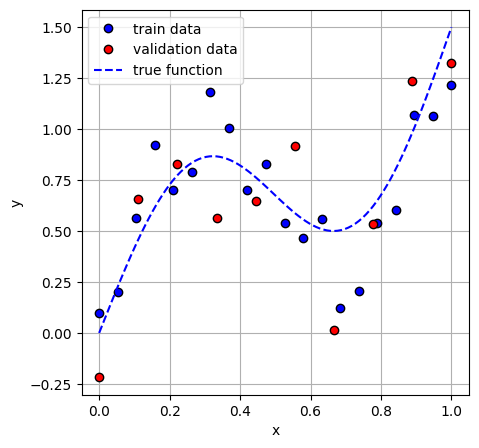

In [21]:
X_train, y_train, y_true_train, true_func = generate_data(n_samples=20, noise_level=0.2)
X_val, y_val, _, _ = generate_data(n_samples=10, noise_level=0.2, random_state=123) # _ is a placeholder variable used when you want to ignore returned values

# Generate test data (more points for smooth plotting)
X_test = np.linspace(0, 1, 100)
y_true_test = true_func(X_test)

plt.figure(figsize=(5, 5))
plt.grid()
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X_train, y_train, "bo", mec="k", label="train data")
plt.plot(X_val, y_val, "ro", mec="k", label="validation data")
plt.plot(X_test, y_true_test, "--b", label="true function")

plt.legend()


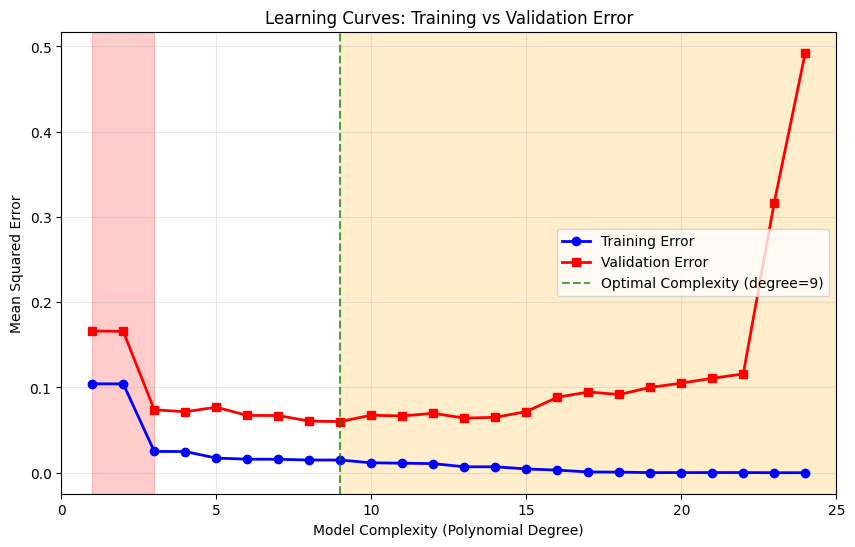

Optimal model complexity: degree 9
Minimum validation error: 0.0601


In [24]:
degrees = range(1, 25)
train_errors = []
val_errors = []

for degree in degrees:
    model = create_polynomial_model(degree)
    model.fit(X_train.reshape(-1, 1), y_train)

    train_pred = model.predict(X_train.reshape(-1, 1))
    val_pred = model.predict(X_val.reshape(-1, 1))

    train_errors.append(mean_squared_error(y_train, train_pred))
    val_errors.append(mean_squared_error(y_val, val_pred))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', color='blue', linewidth=2, label='Training Error')
plt.plot(degrees, val_errors, 's-', color='red', linewidth=2, label='Validation Error')

# Mark the optimal complexity
optimal_idx = np.argmin(val_errors) # In model selection, the optimal complexity is typically the degree (or hyperparameter) where the validation error is lowest
plt.axvline(x=degrees[optimal_idx], color='green', linestyle='--', alpha=0.7,
            label=f'Optimal Complexity (degree={degrees[optimal_idx]})')

plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves: Training vs Validation Error')
plt.legend()
plt.grid(True, alpha=0.3)

# Add regions
plt.axvspan(1, 3, alpha=0.2, color='red', label='Underfitting Region')
plt.axvspan(9, 25, alpha=0.2, color='orange', label='Overfitting Region')
plt.xlim(0, 25)

# plt.yscale('log')  # Log scale to better see the differences
plt.show()

print(f"Optimal model complexity: degree {degrees[optimal_idx]}")
print(f"Minimum validation error: {min(val_errors):.4f}")

## Connection to Linear Systems

Let's consider the problem of fitting a linear model as a system of linear equations.

$X w = y~~ \Leftrightarrow~~ Ax = b$

We can determine the behavior of this linear system by how many equations and variables there are, and the rank of the matrix $X$.


| Linear Algebra | Regression        |
| -------------- | ----------------- |
| A              | X (design matrix) |
| x              | w (weights)       |
| b              | y (targets)       |

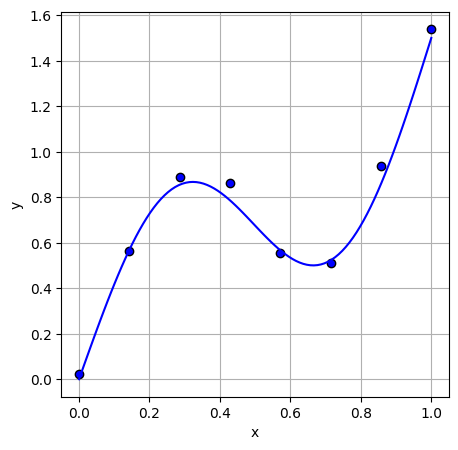

In [25]:
X, y, _, true_func = generate_data(n_samples=8, noise_level=0.05)
X_plot = np.linspace(0, 1, 100)
y_true_plot = true_func(X_plot)

plt.figure(figsize=(5, 5))
plt.grid()
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X, y, "bo", mec="k")
plt.plot(X_plot, y_true_plot, "-b")


In [26]:
X.shape

(8,)

In [27]:
X

array([0.        , 0.14285714, 0.28571429, 0.42857143, 0.57142857,
       0.71428571, 0.85714286, 1.        ])

In [28]:
def create_design_matrix(X, degree):
    """Create design matrix A for polynomial fitting"""
    # design matrix is the matrix that contains all your input features arranged in a structured way so the regression problem can be written as: 𝑋𝑤=𝑦
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    A = poly.fit_transform(X.reshape(-1, 1))
    return A

def analyze_linear_system(A, y):
    """Analyze properties of the linear system Ax = b"""
    m, n = A.shape  # m equations (number of rows), n unknowns (number of columns) = How many variables we are solving for
    rank_A = np.linalg.matrix_rank(A) # calculates how many independent columns (or rows) the matrix has -> rank

    # Compute condition number
    try:
        cond_num = np.linalg.cond(A) # ⁡cond(A) = 𝜎max / 𝜎min
                                     # 𝜎max = largest singular value, 𝜎min = smallest singular value
                                     # singular values come from the Singular Value Decomposition (SVD)
    except:
        cond_num = np.inf

    return {
        'equations': m,
        'unknowns': n,
        'rank': rank_A,
        'condition_number': cond_num,
        'is_overdetermined': m > n,
        'is_underdetermined': m < n,
        'is_well_determined': m == n and rank_A == n,
        'is_rank_deficient': rank_A < min(m, n)
    }

In [29]:
# Different polynomial degrees to create different system types
scenarios = [
    {'degree': 1, 'title': 'Under-parameterized\n(Overdetermined System)', 'color': 'red'},
    {'degree': 7, 'title': 'Well-parameterized\n(Well-determined System)', 'color': 'green'},
    {'degree': 10, 'title': 'Over-parameterized\n(Underdetermined System)', 'color': 'orange'}
]

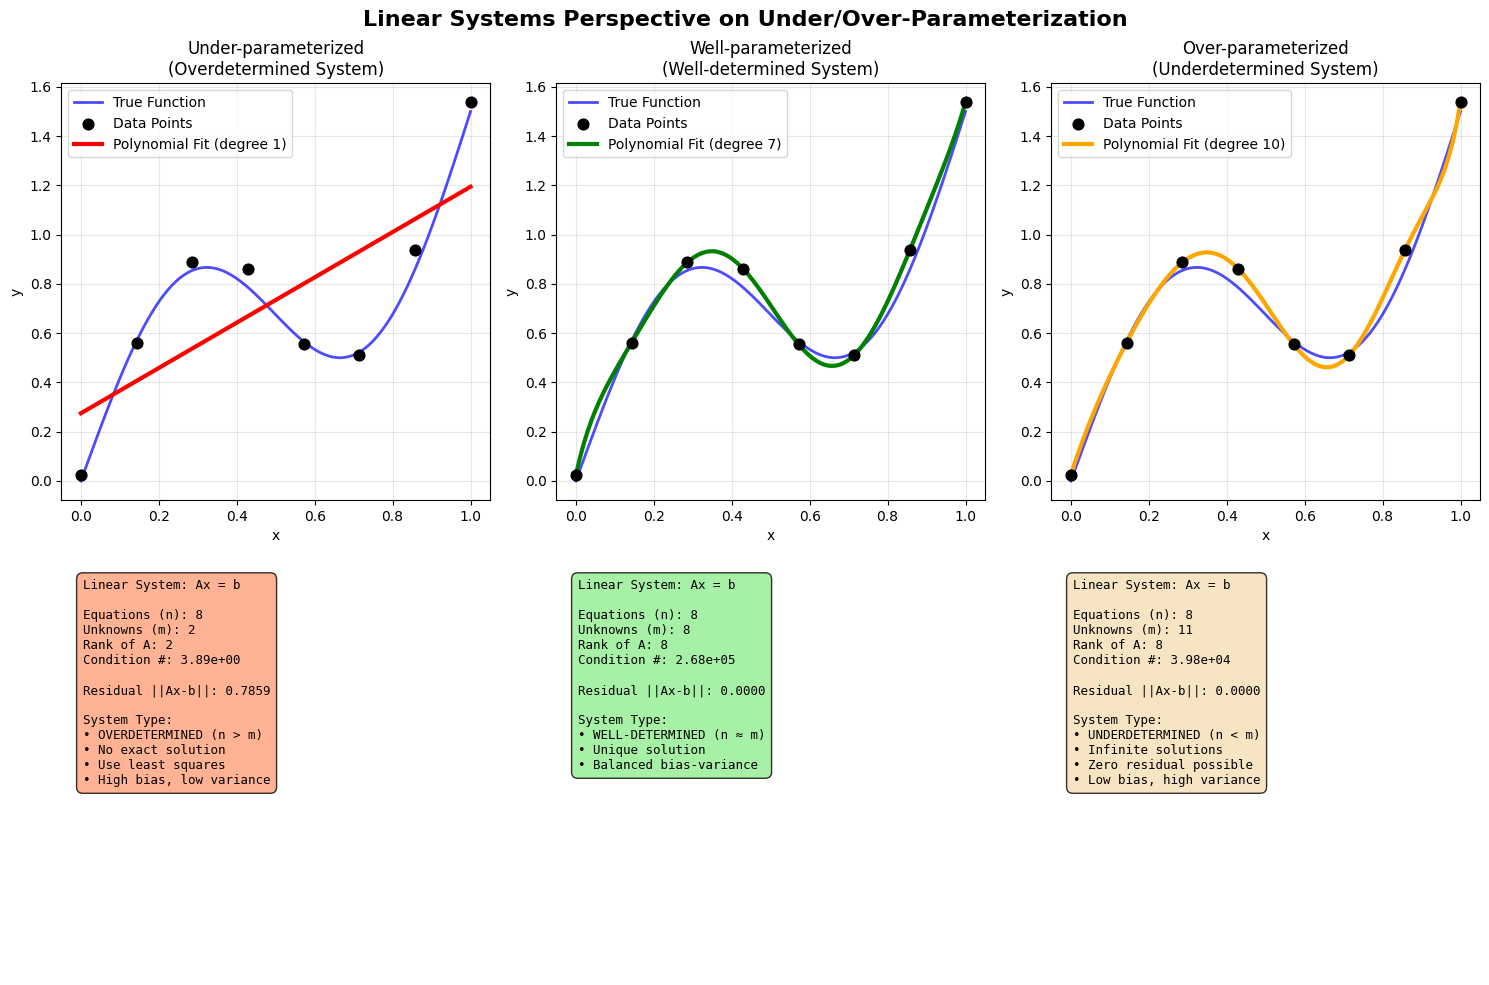

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, scenario in enumerate(scenarios):
    degree = scenario['degree']

    # Create design matrix A
    A = create_design_matrix(X, degree)

    # Analyze the linear system
    sys_info = analyze_linear_system(A, y)

    # Solve the system
    if sys_info['is_underdetermined']:
        # For underdetermined systems, use minimum norm solution
        coeffs = np.linalg.pinv(A) @ y
        residual_norm = np.linalg.norm(A @ coeffs - y)
    else:
        # For overdetermined/well-determined systems, use least squares
        coeffs = np.linalg.lstsq(A, y, rcond=None)[0]
        residual_norm = np.linalg.norm(A @ coeffs - y)

    # Make predictions
    A_plot = create_design_matrix(X_plot, degree)
    y_pred = A_plot @ coeffs

    # Plot 1: Data and fit
    ax1 = axes[0, idx]
    ax1.plot(X_plot, y_true_plot, 'b-', linewidth=2, alpha=0.7, label='True Function')
    ax1.scatter(X, y, color='black', s=60, zorder=5, label='Data Points')
    ax1.plot(X_plot, y_pred, color=scenario['color'], linewidth=3,
            label=f'Polynomial Fit (degree {degree})')

    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title(scenario['title'])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: System properties
    ax2 = axes[1, idx]
    ax2.axis('off')

    # System information
    info_text = f"""Linear System: Ax = b

Equations (n): {sys_info['equations']}
Unknowns (m): {sys_info['unknowns']}
Rank of A: {sys_info['rank']}
Condition #: {sys_info['condition_number']:.2e}

Residual ||Ax-b||: {residual_norm:.4f}

System Type:
"""

    if sys_info['is_overdetermined']:
        info_text += "• OVERDETERMINED (n > m)\n• No exact solution\n• Use least squares\n• High bias, low variance"
        box_color = 'lightsalmon'
    elif sys_info['is_underdetermined']:
        info_text += "• UNDERDETERMINED (n < m)\n• Infinite solutions\n• Zero residual possible\n• Low bias, high variance"
        box_color = 'wheat'
    else:
        info_text += "• WELL-DETERMINED (n ≈ m)\n• Unique solution\n• Balanced bias-variance"
        box_color = 'lightgreen'

    ax2.text(0.05, 0.95, info_text, transform=ax2.transAxes,
            verticalalignment='top', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=box_color, alpha=0.8))

plt.suptitle('Linear Systems Perspective on Under/Over-Parameterization',
              fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Let's assume the matrix $X$ is full-rank. In case when the solution is overer-determined i.e. number of equations (datapoints) $n$ is greater than number of variables (features) $m$, i.e. $n > m$ , we solve a least squares problem: $\min_w \|y - Xw\|^2$.

The solution is given by $w^{*} = (X^T X)^{-1} X^T y$, the Moore–Penrose inverse.

Note that $[(X^T X)^{-1} X^T] \cdot X = (X^T X)^{-1} (X^T X) = I$.

If $n = m$, this formula simplifies to
$w^{*} = X^{-1} y$.

If $n < m$, the system is under-determined, i.e. many $w$ solve it perfectly. Our old formula for linear regression no longer works because $X^T X$ will not be invertible (follows from SVD, excercise). We can define an optimization problem

$$\min_{w} \|w\|_2, \text{s.t.}~~Xw = y.$$

It turns out, that the solution to this problem is still given by the pseudo-inverse: $w^{*} = X^{+} y$, where the pseudoinverse $X^{+}$ is defined via SVD (see https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse).

## Regularization

Let's go back to our simple dat, and try to fit a high-degree polynomial.

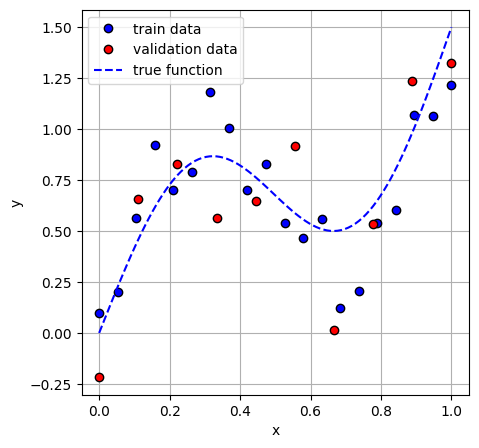

In [31]:
X_train, y_train, y_true_train, true_func = generate_data(n_samples=20, noise_level=0.2)
X_val, y_val, _, _ = generate_data(n_samples=10, noise_level=0.2, random_state=123)

# Generate test data (more points for smooth plotting)
X_test = np.linspace(0, 1, 100)
y_true_test = true_func(X_test)

plt.figure(figsize=(5, 5))
plt.grid()
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X_train, y_train, "bo", mec="k", label="train data")
plt.plot(X_val, y_val, "ro", mec="k", label="validation data")
plt.plot(X_test, y_true_test, "--b", label="true function")

plt.legend()

Overfirtting happens when weights are large: small changes in features lead to big changes in outputs. The model learns to make these large changes to account for the training data (e.g. to fit the noise) in a way that doesn't generalize well. See the weight print outs in the next cell.

We will try to make the weights smaller.
$$\min_w \|X w - y\|^2 + \lambda \|w\|^2$$

Here $\|w\|$ is the regularization term, which can have different shapes. Effectively, we trade off fitting the data vs the complexity of the solution.

We will start with L2 regularization $\|w\|_2^2$. Let's see what happens as we increase $\lambda$.

alpha=0.0 fit: 9.9E-02 0.0E+00 x^1 +5.6E+02 x^2 -3.0E+04 x^3 +6.7E+05 x^4 -8.2E+06 x^5 +6.4E+07 x^6 -3.4E+08 x^7 +1.3E+09 x^8 -3.4E+09 x^9 +6.6E+09 x^10 -9.6E+09 x^11 +1.0E+10 x^12 -7.4E+09 x^13 +3.6E+09 x^14 -1.1E+09 x^15 +1.4E+08 x^16
alpha=0.001 fit: 1.2E-01 0.0E+00 x^1 +4.8E+00 x^2 -6.1E+00 x^3 -3.4E+00 x^4 +1.1E-01 x^5 +2.1E+00 x^6 +2.7E+00 x^7 +2.4E+00 x^8 +1.7E+00 x^9 +8.9E-01 x^10 +1.3E-01 x^11 -4.8E-01 x^12 -8.8E-01 x^13 -1.1E+00 x^14 -1.0E+00 x^15 -8.2E-01 x^16
alpha=0.01 fit: 3.2E-01 0.0E+00 x^1 +2.7E+00 x^2 -2.8E+00 x^3 -2.1E+00 x^4 -5.6E-01 x^5 +6.2E-01 x^6 +1.2E+00 x^7 +1.4E+00 x^8 +1.3E+00 x^9 +1.1E+00 x^10 +7.0E-01 x^11 +2.9E-01 x^12 -1.3E-01 x^13 -5.4E-01 x^14 -9.2E-01 x^15 -1.3E+00 x^16
alpha=0.1 fit: 5.5E-01 0.0E+00 x^1 +6.0E-01 x^2 -6.0E-01 x^3 -5.3E-01 x^4 -2.2E-01 x^5 +5.0E-02 x^6 +2.2E-01 x^7 +3.0E-01 x^8 +3.2E-01 x^9 +3.0E-01 x^10 +2.4E-01 x^11 +1.8E-01 x^12 +1.0E-01 x^13 +2.1E-02 x^14 -5.9E-02 x^15 -1.4E-01 x^16


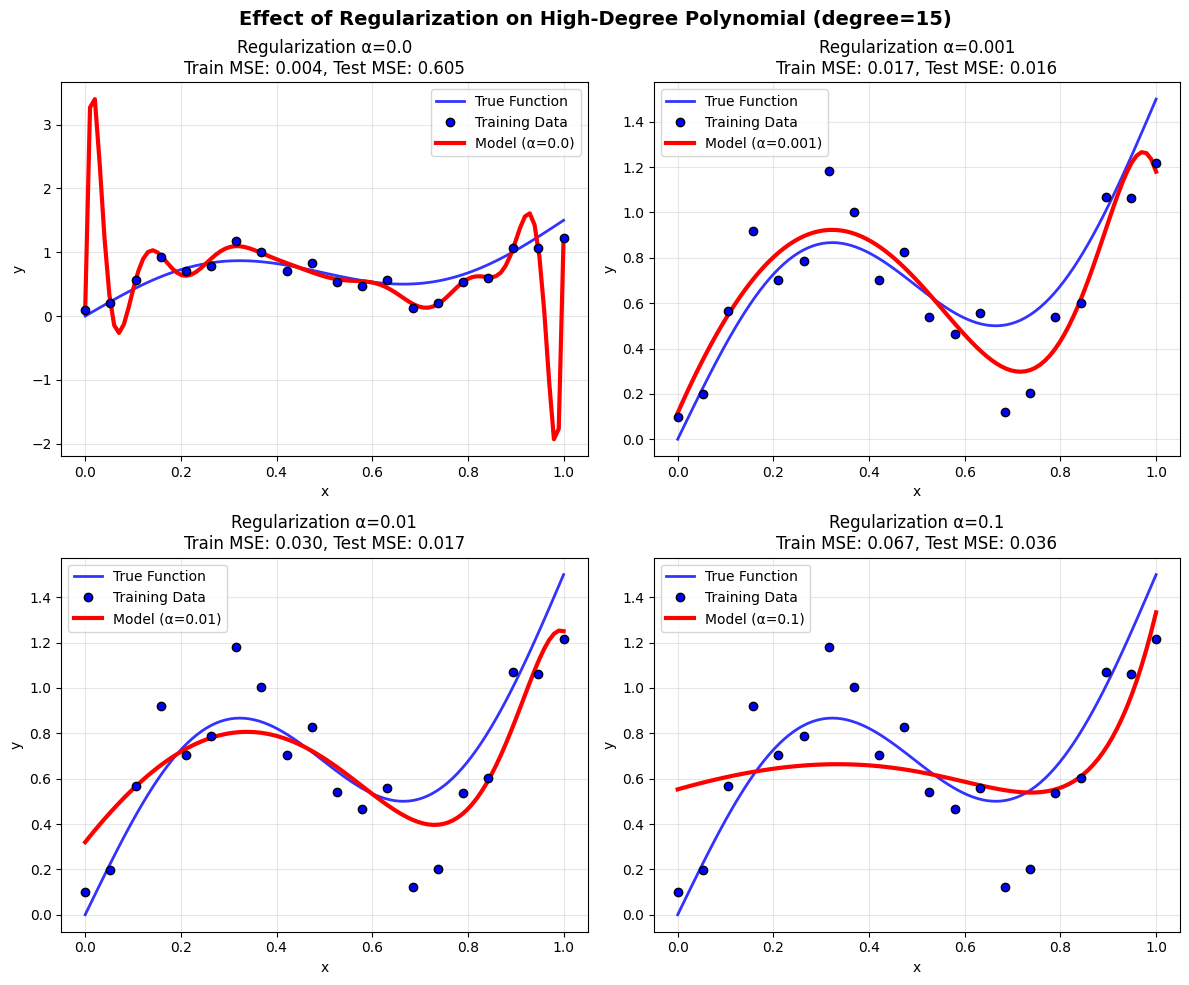

In [32]:
# High degree polynomial with different regularization strengths
degree = 15
alphas = [0.0, 0.001, 0.01, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, alpha in enumerate(alphas):
    ax = axes[idx]

    # Create and train model
    model = create_polynomial_model(degree, alpha)
    model.fit(X_train.reshape(-1, 1), y_train)

    linreg = model.steps[-1][1] # take the last step in the pipeline (extract the actual regression model)
    bias = linreg.intercept_
    weights = linreg.coef_
    print(f"{alpha=} fit: {bias:.1E} " + " ".join([("+" if w > 0 else "") + f"{w:.1E} x^{n+1}" for n, w in enumerate(weights)]))

    # Make predictions
    y_pred = model.predict(X_test.reshape(-1, 1))
    train_pred = model.predict(X_train.reshape(-1, 1))

    # Calculate errors
    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_true_test, y_pred)

    # Plot
    ax.plot(X_test, y_true_test, 'b-', linewidth=2, alpha=0.8, label='True Function')
    ax.plot(X_train, y_train, 'bo', mec="k", zorder=5, label='Training Data')
    ax.plot(X_test, y_pred, 'r-', linewidth=3, label=f'Model (α={alpha})')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    title = f'Regularization α={alpha}\nTrain MSE: {train_error:.3f}, Test MSE: {test_error:.3f}'
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Effect of Regularization on High-Degree Polynomial (degree={degree})',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# L2-Regularized Linear Regression Derivation

## Problem Statement

We want to find the optimal weight vector $w$ that minimizes the L2-regularized linear regression objective:

$$\min_w \|Xw - y\|^2 + \lambda \cdot \|w\|^2$$

where:
- $X \in \mathbb{R}^{n \times d}$ is the design matrix with $n$ samples and $d$ features
- $w \in \mathbb{R}^{d}$ is the weight vector we want to optimize
- $y \in \mathbb{R}^{n}$ is the target vector
- $\lambda \geq 0$ is the regularization parameter

## Step 1: Expand the Objective Function

First, let's expand the squared norms:

$$\|Xw - y\|^2 = (Xw - y)^T(Xw - y)$$

$$\|w\|^2 = w^T w$$

So our objective function becomes:

$$J(w) = (Xw - y)^T(Xw - y) + \lambda w^T w$$

## Step 2: Expand the First Term

Let's expand $(Xw - y)^T(Xw - y)$:

$$\begin{align}
(Xw - y)^T(Xw - y) &= (w^TX^T - y^T)(Xw - y) \\
&= w^TX^TXw - w^TX^Ty - y^TXw + y^Ty \\
&= w^TX^TXw - 2w^TX^Ty + y^Ty
\end{align}$$

Note that $w^TX^Ty = y^TXw$ since both are scalars and equal to their transpose.

## Step 3: Write the Complete Objective

Substituting back into our objective function:

$$J(w) = w^TX^TXw - 2w^TX^Ty + y^Ty + \lambda w^T w$$

$$J(w) = w^T(X^TX + \lambda I)w - 2w^TX^Ty + y^Ty$$

where $I$ is the $d \times d$ identity matrix.

## Step 4: Take the Gradient

To find the minimum, we take the gradient with respect to $w$ and set it equal to zero:

$$\frac{\partial J(w)}{\partial w} = 2(X^TX + \lambda I)w - 2X^Ty$$

Using the matrix calculus identities:
- $\frac{\partial}{\partial w}(w^TAw) = 2Aw$ for symmetric matrix $A$
- $\frac{\partial}{\partial w}(a^Tw) = a$ for vector $a$

## Step 5: Set Gradient to Zero

Setting the gradient equal to zero:

$$2(X^TX + \lambda I)w - 2X^Ty = 0$$

$$\Rightarrow (X^TX + \lambda I)w = X^Ty$$

## Step 6: Solve for Optimal Weights

Assuming $(X^TX + \lambda I)$ is invertible, we can solve for $w$:

$$w^* = (X^TX + \lambda I)^{-1}X^Ty$$

## Step 7: Verify Second-Order Condition

To confirm this is indeed a minimum, we check the second derivative (Hessian):

$$\frac{\partial^2 J(w)}{\partial w^2} = 2(X^TX + \lambda I)$$

Since $X^TX$ is positive semidefinite and $\lambda I$ (with $\lambda \geq 0$) is positive semidefinite, their sum $X^TX + \lambda I$ is positive semidefinite. When $\lambda > 0$, it's actually positive definite, guaranteeing a unique global minimum.

## Final Result

The optimal solution to L2-regularized linear regression is:

$$\boxed{w^* = (X^TX + \lambda I)^{-1}X^Ty}$$

## Notes

1. **Invertibility**: When $\lambda > 0$, the matrix $(X^TX + \lambda I)$ is always invertible, even when $X^TX$ is singular. This is one of the key advantages of ridge regression.

2. **Special Cases**:
   - When $\lambda = 0$, this reduces to ordinary least squares: $w^* = (X^TX)^{-1}X^Ty$
   - As $\lambda \to \infty$, we get $w^* \to 0$

3. **Computational Complexity**: Direct matrix inversion has complexity $O(d^3)$. For large $d$, iterative methods or the singular value decomposition can be more efficient.

Let's see what happens to the train and validation loss when we have regularization. Compare to the baseline above with no regularization.

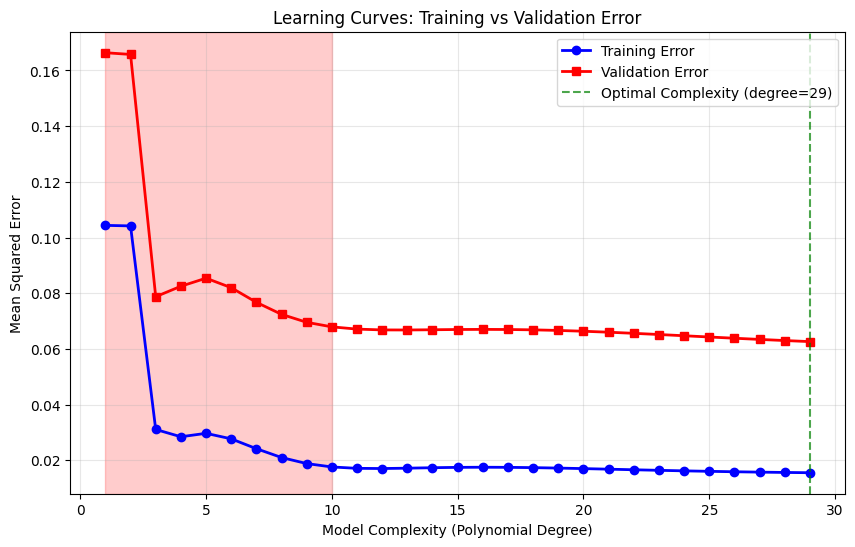

Optimal model complexity: degree 29
Minimum validation error: 0.0626


In [ ]:
degrees = range(1, 30)
train_errors = []
val_errors = []
alpha = 0.001

for degree in degrees:
    model = create_polynomial_model(degree, alpha)
    model.fit(X_train.reshape(-1, 1), y_train)

    train_pred = model.predict(X_train.reshape(-1, 1))
    val_pred = model.predict(X_val.reshape(-1, 1))

    train_errors.append(mean_squared_error(y_train, train_pred))
    val_errors.append(mean_squared_error(y_val, val_pred))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', color='blue', linewidth=2, label='Training Error')
plt.plot(degrees, val_errors, 's-', color='red', linewidth=2, label='Validation Error')

# Mark the optimal complexity
optimal_idx = np.argmin(val_errors)
plt.axvline(x=degrees[optimal_idx], color='green', linestyle='--', alpha=0.7,
            label=f'Optimal Complexity (degree={degrees[optimal_idx]})')

plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves: Training vs Validation Error')
plt.legend()
plt.grid(True, alpha=0.3)

# # Add regions
plt.axvspan(1, 10, alpha=0.2, color='red', label='Underfitting Region')
# plt.axvspan(9, 25, alpha=0.2, color='orange', label='Overfitting Region')
# plt.xlim(0, 25)

# plt.yscale('log')  # Log scale to better see the differences
plt.show()

print(f"Optimal model complexity: degree {degrees[optimal_idx]}")
print(f"Minimum validation error: {min(val_errors):.4f}")

## Regularization Geometry

Let's consider a related problem of $$\min \|X w - y\|^2,~\text{s.t.}~~\|w\| < \alpha.$$

On the level set of the loss, we will find the point with the lowest norm. See https://i.redd.it/mmvqbykjraid1.png.

Now, let's consider l_1 regularization.
$$\min \|X w - y\|^2 + \lambda \|w\|_1,$$
or
$$\min \|X w - y\|^2,~\text{s.t.}~~\|w\|_1 < \alpha.$$

- The level set of L1-norm is a polyhedron.
- The minimizer will end up in a vertex of the polyhedron.
- L1-regularization produces sparse solutions!





alpha=0.0 fit: 9.9E-02 0.0E+00 x^1 +5.6E+02 x^2 -3.0E+04 x^3 +6.7E+05 x^4 -8.2E+06 x^5 +6.4E+07 x^6 -3.4E+08 x^7 +1.3E+09 x^8 -3.4E+09 x^9 +6.6E+09 x^10 -9.6E+09 x^11 +1.0E+10 x^12 -7.4E+09 x^13 +3.6E+09 x^14 -1.1E+09 x^15 +1.4E+08 x^16
alpha=0.001 fit: 2.5E-01 0.0E+00 x^1 +3.7E+00 x^2 -5.8E+00 x^3 -0.0E+00 x^4 0.0E+00 x^5 0.0E+00 x^6 +3.3E+00 x^7 +1.1E+00 x^8 0.0E+00 x^9 0.0E+00 x^10 0.0E+00 x^11 0.0E+00 x^12 -0.0E+00 x^13 -0.0E+00 x^14 -0.0E+00 x^15 -1.1E+00 x^16
alpha=0.01 fit: 6.1E-01 0.0E+00 x^1 0.0E+00 x^2 -0.0E+00 x^3 -0.0E+00 x^4 0.0E+00 x^5 0.0E+00 x^6 0.0E+00 x^7 0.0E+00 x^8 0.0E+00 x^9 0.0E+00 x^10 +4.6E-01 x^11 +7.2E-02 x^12 0.0E+00 x^13 0.0E+00 x^14 0.0E+00 x^15 0.0E+00 x^16
alpha=0.1 fit: 6.7E-01 0.0E+00 x^1 0.0E+00 x^2 0.0E+00 x^3 0.0E+00 x^4 0.0E+00 x^5 0.0E+00 x^6 0.0E+00 x^7 0.0E+00 x^8 0.0E+00 x^9 0.0E+00 x^10 0.0E+00 x^11 0.0E+00 x^12 0.0E+00 x^13 0.0E+00 x^14 0.0E+00 x^15 0.0E+00 x^16


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.811e-03, tolerance: 2.262e-04
  model = cd_fast.enet_coordinate_descent(


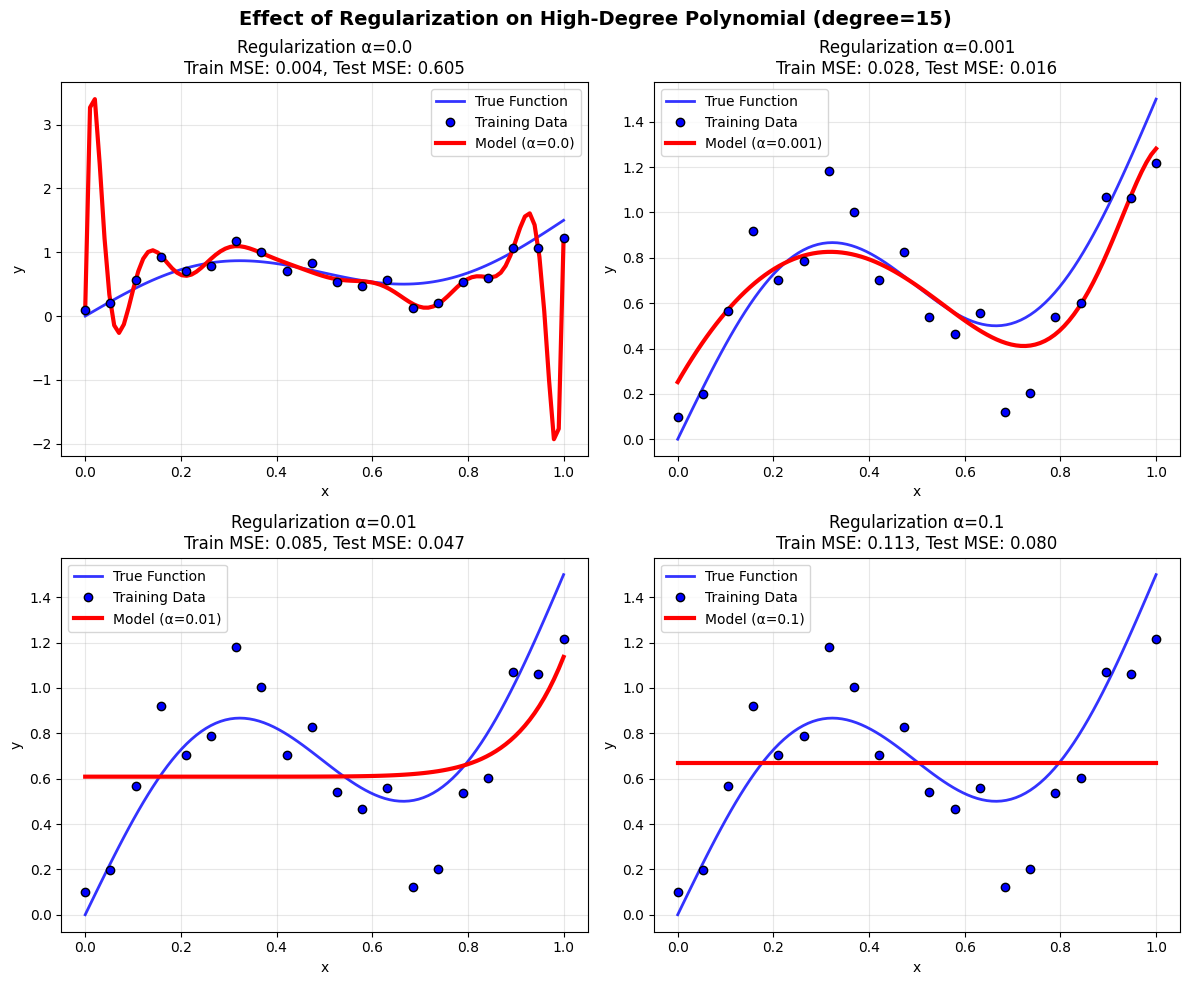

In [ ]:
# High degree polynomial with different regularization strengths
degree = 15
alphas = [0.0, 0.001, 0.01, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, alpha in enumerate(alphas):
    ax = axes[idx]

    # Create and train model
    model = create_polynomial_model(degree, alpha, l1=True)
    model.fit(X_train.reshape(-1, 1), y_train)

    linreg = model.steps[-1][1]
    bias = linreg.intercept_
    weights = linreg.coef_
    print(f"{alpha=} fit: {bias:.1E} " + " ".join([("+" if w > 0 else "") + f"{w:.1E} x^{n+1}" for n, w in enumerate(weights)]))

    # Make predictions
    y_pred = model.predict(X_test.reshape(-1, 1))
    train_pred = model.predict(X_train.reshape(-1, 1))

    # Calculate errors
    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_true_test, y_pred)

    # Plot
    ax.plot(X_test, y_true_test, 'b-', linewidth=2, alpha=0.8, label='True Function')
    ax.plot(X_train, y_train, 'bo', mec="k", zorder=5, label='Training Data')
    ax.plot(X_test, y_pred, 'r-', linewidth=3, label=f'Model (α={alpha})')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    title = f'Regularization α={alpha}\nTrain MSE: {train_error:.3f}, Test MSE: {test_error:.3f}'
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Effect of Regularization on High-Degree Polynomial (degree={degree})',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Elastic net regularization
$$\min_{w} \|Xw - y\|^2 + \lambda_1 \|w\|^2_2 + \lambda_2 \|w\|_1$$